In [1]:
import pandas as pd

df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [5]:
df['Geography'].value_counts()


Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [6]:
df['Gender'].value_counts()


Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [7]:
df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'], inplace = True)

In [8]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df = pd.get_dummies(
    df,
    columns=['Geography', 'Gender'],
    drop_first=True,
    dtype=int
)

In [10]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [11]:
X = df.drop(columns=['Exited'])
y = df['Exited']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [12]:
X_train.shape

(8000, 11)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [30]:
X_train_scaled

array([[-2.97370426, -0.85172017, -1.73035313, ...,  1.72271934,
        -0.56989252,  0.91659043],
       [-1.0220026 , -0.08916797, -1.38304522, ..., -0.58047761,
         1.75471685,  0.91659043],
       [ 1.31381055, -0.94703919,  0.35349433, ...,  1.72271934,
        -0.56989252, -1.09099983],
       ...,
       [ 0.41062946, -1.04235821, -1.38304522, ..., -0.58047761,
        -0.56989252,  0.91659043],
       [ 1.10618271, -0.37512504,  0.00618642, ..., -0.58047761,
         1.75471685,  0.91659043],
       [-1.10505374, -1.23299626,  0.70080224, ..., -0.58047761,
        -0.56989252,  0.91659043]], shape=(6400, 11))

In [31]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [32]:
model = Sequential()

model.add(Dense(3,activation = 'sigmoid',input_dim = 11))
model.add(Dense(1,activation = 'sigmoid'))


c:\Users\LENOVO\ML-PRACTICE-PROJECTS\churn-prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [52]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [53]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8197 - loss: 0.4308 - val_accuracy: 0.8138 - val_loss: 0.4166
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8223 - loss: 0.4296 - val_accuracy: 0.8150 - val_loss: 0.4154
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8228 - loss: 0.4287 - val_accuracy: 0.8169 - val_loss: 0.4143
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8236 - loss: 0.4278 - val_accuracy: 0.8163 - val_loss: 0.4133
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8245 - loss: 0.4269 - val_accuracy: 0.8150 - val_loss: 0.4123
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8255 - loss: 0.4261 - val_accuracy: 0.8138 - val_loss: 0.4114
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8253 - loss: 0.4254 - val_accuracy: 0.8175 - val_loss: 0.4106
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8261 - loss: 0.4247 - val_accuracy: 0.

In [54]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [55]:
import matplotlib.pyplot as plt


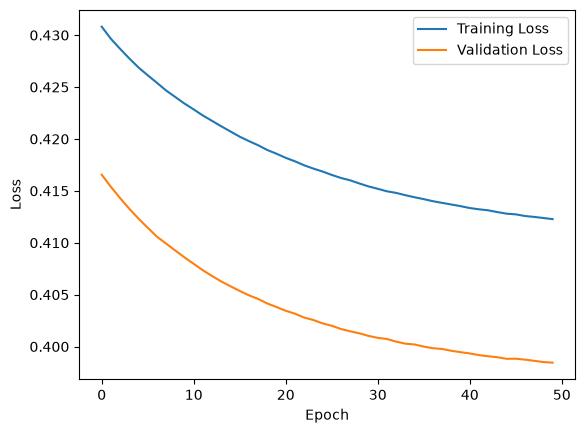

In [56]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Training Loss', 'Validation Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

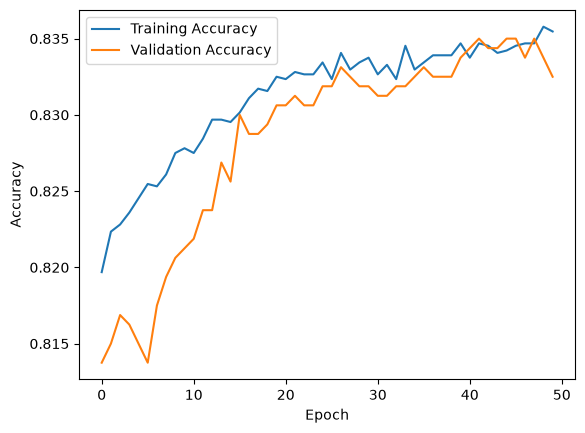

In [57]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [58]:
model.layers[0].get_weights()

[array([[ 0.2680125 , -0.21943164,  0.08788434],
        [-3.349334  ,  2.9767406 ,  0.12268098],
        [ 0.11216299, -0.01599374, -0.05335625],
        [ 0.01248094,  0.38007635,  0.50048345],
        [ 0.05051091, -0.02187404, -0.28056055],
        [ 0.01813617,  0.19116424,  0.10711337],
        [-0.47569674,  0.62909263, -2.3421295 ],
        [ 0.11303388, -0.3437423 ,  0.10097749],
        [-0.30500084,  0.29753503,  1.2071613 ],
        [-0.0301822 ,  0.22356571,  0.08818924],
        [ 0.09840486, -0.31389442, -0.81578326]], dtype=float32),
 array([ 0.90047276, -0.23641428, -0.71988684], dtype=float32)]

In [59]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [60]:
import numpy as np

In [61]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [62]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.838

In [63]:
val_loss, val_accuracy = model.evaluate(X_val_scaled, y_val)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8325 - loss: 0.3984
Validation Loss: 0.3984455168247223
Validation Accuracy: 0.8324999809265137


In [64]:
from sklearn.metrics import confusion_matrix

In [65]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1542   65]
 [ 259  134]]


In [66]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.6733668341708543
Recall: 0.34096692111959287
F1 Score: 0.4527027027027027
